# K-Means Clustering

Instructor: Amna Mazen

## Import Libraries

In [52]:
import os
import random
import sys
import time

import numpy as np

sys.path.append("code/.")
import matplotlib.pyplot as plt
import seaborn as sns
#from plotting_functions import *
#from plotting_functions_unsup import *
from sklearn import cluster, datasets, metrics
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import euclidean_distances


#plt.style.use("seaborn")

%matplotlib inline

In [53]:
!pip install mglearn

## Helpful custom functions

In [54]:
def update_Z(X, centers):
    """
    returns distances and updated cluster assignments
    """
    dist = euclidean_distances(X, centers)
    return dist, np.argmin(dist, axis=1)

In [55]:
def plot_current_assinment(X, Z, centers, colours=['black','blue','red']):
    plt.scatter(X[:,0], X[:,1], c=[colours[z] for z in Z], marker='o')
    plt.scatter(centers[:,0], centers[:,1], c=colours, marker='*',s=200)
    plt.title('Current cluster assignment')

In [56]:
def update_centers(X, Z, old_centers, k):
    """
    returns new centers
    """
    new_centers = old_centers.copy()
    for kk in range(k):
        new_centers[kk] = np.mean(X[Z == kk], axis=0)
    return new_centers

In [57]:
def plot_update_centroid(data, w, h, new_centroids, centroids, dist):
    colors = np.array(['black', 'blue', 'red', 'green', 'purple'])
    plt.figure(figsize=(w, h))
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1],
                c=colors[np.argmin(dist, 1)])
    plt.scatter(centroids[:, 0], centroids[:, 1], s=300,
                marker='*', color=['black', 'blue', 'red'])
    plt.xlabel("$X_1$", fontdict={'fontsize': w})
    plt.ylabel("$X_2$", fontdict={'fontsize': w})
    plt.title("Update the centroids - Step #2", fontdict={'fontsize': w+h})
    plt.scatter(new_centroids[:, 0], new_centroids[:, 1],
                s=300, marker='*', color=['black', 'blue', 'red'])

    aux = new_centroids-(centroids+(new_centroids-centroids)*0.9)
    aux = np.linalg.norm(aux, axis=1)
    for i in range(0, 3):
        plt.arrow(centroids[i, 0], centroids[i, 1],
                  (new_centroids[i, 0]-centroids[i, 0])*0.8,
                  (new_centroids[i, 1]-centroids[i, 1])*0.8,
                  head_width=.1, head_length=aux[i], fc=colors[i], ec=colors[i])

In [58]:
def plot_example_dist(data, centroids, w, h, point=None):
    """
    Plot the distance of a point to the centroids.

    Parameters:
    -----------
    data: pd.DataFrame
        A pandas dataframe with X1 and X2 coordinate. If more than two
        coordinates, only the first two will be used.
    centroids: pd.DataFrame
        A pandas dataframe composed by k rows of data, chosen randomly. (where k
        stands for the number of clusters)
    w: int
        width of the plot
    h: int
        height of the plot
    point: int
        the index of the point to be used to calculate the distance
    """

    colors = np.array(['black', 'blue', 'red', 'green', 'purple'])
    k = centroids.shape[0]
    if point is None:
        point = np.random.choice(range(0, data.shape[0]), size=1)

    point = data.iloc[point, 0:2].to_numpy()[0]
    centroids = centroids.iloc[:, 0:2].to_numpy()

    plt.figure(figsize=(w, h))
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1])
    plt.scatter(centroids[:, 0], centroids[:, 1], s=250,
                marker='*', color=['black', 'blue', 'red'])
    plt.xlabel(data.columns[0], fontdict={'fontsize': w})
    plt.ylabel(data.columns[1], fontdict={'fontsize': w})
    plt.scatter(point[0], point[1], c="orange", s=120)

    dist = np.zeros(k)
    for i in range(0, k):
        l = np.row_stack((point, centroids[i, :]))
        dist[i] = np.sum((point-centroids[i, :])**2)**0.5
        plt.plot(l[:, 0], l[:, 1], c=colors[i], linewidth=1, linestyle='-.')
        if (l[0, 1] <= l[1, 1]):
            plt.text(l[1, 0]-.15, l[1, 1]+.05,
                     f"d = {np.round(dist[i], 2)}", color=colors[i],
                     fontdict={'fontsize': (w+h)/2})
        else:
            plt.text(l[1, 0]-.15, l[1, 1]-.11,
                     f"d = {np.round(dist[i], 2)}", color=colors[i],
                     fontdict={'fontsize': (w+h)/2})

    plt.title(f"This point will be assign to the {colors[np.argmin(dist)]}" +
              " cluster", fontdict={'fontsize': w+h})

In [59]:
def plot_unsup(data, w, h, title=None):
    """
    Function to generate unsupervised plot.

    Parameters:
    -----------
    data: pd.DataFrame
        A pandas dataframe with X1 and X2 coordinate. If more than two
        coordinates, only the first two will be used.
    w: int
        Width of the plot
    h: int
        height of the plot
    title: str
        the tile of the plot
    """

    plt.figure(figsize=(w, h))
    ax = plt.gca()
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1])
    plt.title(title, fontdict={'fontsize': 1.2*(w + h)})
    plt.xlabel(data.columns[0], fontsize=1.2*w)
    plt.ylabel(data.columns[1], fontsize=1.2*w)

In [60]:
def plot_first_assignment(data, centroids, dist, w, h):
    """
    Plot the points after the first assignment.

    Parameters:
    -----------
    data: pd.DataFrame
        A pandas dataframe with X1 and X2 coordinate. If more than two
        coordinates, only the first two will be used.
    centroids: pd.DataFrame
        A pandas dataframe composed by k rows of data, chosen randomly. (where k
        stands for the number of clusters)
    dist: a matrix of distance of each point to all the centroids.
          [See scipy.spatial.distance.cdist]
    w: int
        width of the plot
    h: int
        height of the plot
    """

    k = centroids.shape[0]
    colors = np.array(['black', 'blue', 'red', 'green', 'purple'])

    plt.figure(figsize=(w, h))
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1],
                c=colors[np.argmin(dist, 1)])
    plt.scatter(centroids.iloc[:, 0],
                centroids.iloc[:, 1],
                s=300, marker='*', color=colors[0:k])
    plt.xlabel(data.columns[0], fontdict={'fontsize': w})
    plt.ylabel(data.columns[1], fontdict={'fontsize': w})

    plt.title("First round of assignment - Step #1",
              fontdict={'fontsize': w+h})

In [61]:
def plot_intial_center(data, centroids, w, h, title=None):
    """
    Plot the initial centroids.

    Parameters:
    -----------
    data: pd.DataFrame
        A pandas dataframe with X1 and X2 coordinate. If more than two
        coordinates, only the first two will be used.
    centroids: pd.DataFrame
        A pandas dataframe composed by k rows of data, chosen randomly. (where k
        stands for the number of clusters)
    w: int
        width of the plot
    h: int
        height of the plot
    title: str
        the tile of the plot
    """
    n_clusters = centroids.shape[0]

    colors = np.array(['black', 'blue', 'red', 'green', 'purple'])
    data = data.iloc[:, 0:2]
    centroids = centroids.to_numpy()
    plt.figure(figsize=(w, h))
    plt.scatter(data.iloc[:, 0], data.iloc[:, 1], marker='o')
    plt.scatter(centroids[:, 0], centroids[:, 1], s=250,
                marker='*', color=colors[0:n_clusters])
    plt.xlabel(data.columns[0], fontdict={'fontsize': w})
    plt.ylabel(data.columns[1], fontdict={'fontsize': w})
    plt.title(title, fontdict={'fontsize': (w + h)})
    ax = plt.gca()

In [62]:
def plot_iterative(data, w, h, starting_centroid):
    k = starting_centroid.shape[0]
    colors = np.array(['black', 'blue', 'red', 'green', 'purple'])
    x = data.iloc[:, 0:2].to_numpy()
    plt.figure(figsize=(w, h))
    centroids = starting_centroid.copy()
    for i in range(0, 5):
        dist = distance.cdist(x, centroids)
        u = np.zeros((k, x.shape[0]))
        u[np.argmin(dist, axis=1), range(0, data.shape[0])] = 1
        new_centroids = u @ x / np.sum(u, 1)[:, None]
        plt.scatter(centroids[:, 0], centroids[:, 1], s=300,
                    marker='*', color=['black', 'blue', 'red'])
        plt.scatter(new_centroids[:, 0], new_centroids[:, 1],
                    s=200, marker='*', color=['black', 'blue', 'red'])

        aux = new_centroids-(centroids+(new_centroids-centroids)*0.9)
        aux = np.linalg.norm(aux, axis=1)
        for i in range(0, 3):
            if aux[i] > .005:
                plt.arrow(centroids[i, 0], centroids[i, 1],
                          (new_centroids[i, 0]-centroids[i, 0])*0.8,
                          (new_centroids[i, 1]-centroids[i, 1])*0.8,
                          head_width=.1, head_length=aux[i], fc=colors[i], ec=colors[i])
        centroids = new_centroids

    plt.scatter(x[:, 0], x[:, 1], c=colors[np.argmin(dist, 1)], alpha=.25)
    plt.xlabel(data.columns[0], fontdict={'fontsize': w})
    plt.ylabel(data.columns[1], fontdict={'fontsize': w})
    plt.title("Iterative process", fontdict={'fontsize': w+h})

## K-Means clustering algorithm

### K-Means clustering

One of the most commonly used clustering algorithm.

**Input**
- `X` $\rightarrow$ a set of data points  
- `K` (or $k$ or `n_clusters`) $\rightarrow$ number of clusters

**Output**
- `K` clusters (groups) of the data points



### K-Means using `sklearn`
- Before understanding the algorithm, let's try it with `sklearn`.
- Consider the toy dataset above.
- For this toy dataset, the three clusters are pretty clear.  

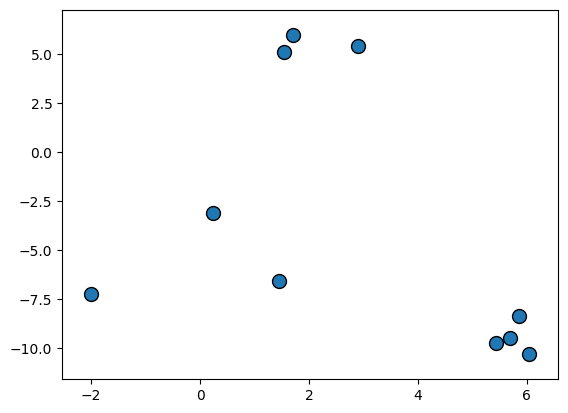

In [63]:
import mglearn
X, y = make_blobs(n_samples=10, centers=3, n_features=2, random_state=10)
mglearn.discrete_scatter(X[:, 0], X[:, 1], markers="o")

In [64]:
X

array([[  5.69192445,  -9.47641249],
       [  1.70789903,   6.00435173],
       [  0.23621041,  -3.11909976],
       [  2.90159483,   5.42121526],
       [  5.85943906,  -8.38192364],
       [  6.04774884, -10.30504657],
       [ -2.00758803,  -7.24743939],
       [  1.45467725,  -6.58387198],
       [  1.53636249,   5.11121453],
       [  5.4307043 ,  -9.75956122]])

In [65]:
import pandas as pd
toy_df = pd.DataFrame(data=X, columns=["feat1", "feat2"])
toy_df

,feat1,feat2
0,5.691924,-9.476412
1,1.707899,6.004352
2,0.236210,-3.119100
3,2.901595,5.421215
4,5.859439,-8.381924
5,6.047749,-10.305047
6,-2.007588,-7.247439
7,1.454677,-6.583872
8,1.536362,5.111215
9,5.430704,-9.759561


#### `KMeans` `fit`
Let's try `sklearn`'s `KMeans` algorithm on this dataset.
- We need to decide how many clusters we want. Here we are passing 3.
- We are only passing `X` because this is unsupervised learning; we do not have labels.  

In [66]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(X)
# We are only passing X because this is unsupervised learning

KMeans(n_clusters=3)

#### `predict` of `KMeans`

- The output of `KMeans` is $K$ clusters (groups) of the data points.
- Calling `predict` will give us the cluster assignment for each data point.

In [67]:
kmeans.predict(X)

array([0, 1, 2, 1, 0, 0, 2, 2, 1, 0], dtype=int32)

In [68]:
toy_df_cl = toy_df.copy()
toy_df_cl["cluster"] = kmeans.predict(toy_df)
toy_df_cl

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(


,feat1,feat2,cluster
0,5.691924,-9.476412,0
1,1.707899,6.004352,1
2,0.236210,-3.119100,2
3,2.901595,5.421215,1
4,5.859439,-8.381924,0
5,6.047749,-10.305047,0
6,-2.007588,-7.247439,2
7,1.454677,-6.583872,2
8,1.536362,5.111215,1
9,5.430704,-9.759561,0


#### Cluster centers in  K-Means

- In K-Means each cluster is represented by its cluster center.

In [69]:
kmeans.cluster_centers_

array([[ 5.75745416, -9.48073598],
       [ 2.04861878,  5.51226051],
       [-0.10556679, -5.65013704]])

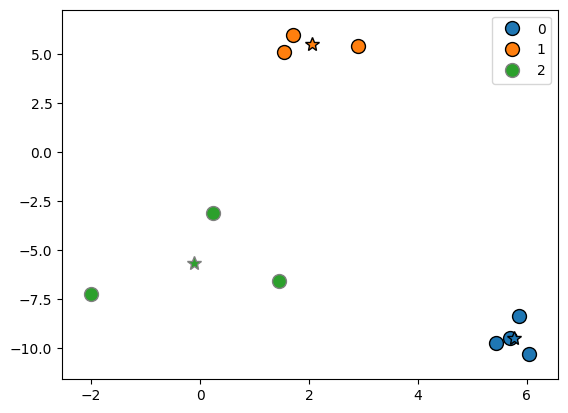

In [70]:
mglearn.discrete_scatter(X[:, 0], X[:, 1], kmeans.labels_, markers="o")
plt.legend()
mglearn.discrete_scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], [0, 1, 2], markers="*"
);

### K-Means clustering algorithm

**Input**: Data points X and the number of clusters K

**Initialization**: K initial centers for the clusters

**Iterative process**:

repeat
- Assign each example to the closest center.
- Calculate new centers as _average_ of samples in a cluster.

until **centers stop changing** or **maximum iterations have reached**.

Let's execute K-Means algorithm on our toy example.

**Input**
- The data points `X`

In [71]:
n_examples = toy_df.shape[0]
print("Number of examples: ", n_examples)
X

Number of examples:  10


array([[  5.69192445,  -9.47641249],
       [  1.70789903,   6.00435173],
       [  0.23621041,  -3.11909976],
       [  2.90159483,   5.42121526],
       [  5.85943906,  -8.38192364],
       [  6.04774884, -10.30504657],
       [ -2.00758803,  -7.24743939],
       [  1.45467725,  -6.58387198],
       [  1.53636249,   5.11121453],
       [  5.4307043 ,  -9.75956122]])

- Let K (number of clusters) be 3.

In [72]:
k = 3

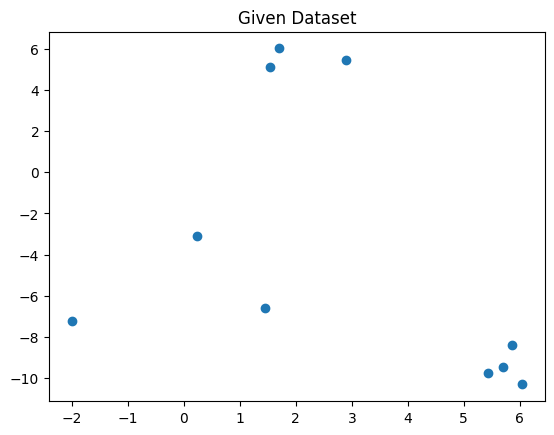

In [73]:
plt.scatter(X[:, 0], X[:, 1], marker="o")
plt.title("Given Dataset");

#### Initialization

- Random initialization for K initial centers of the clusters.

In [74]:
np.random.seed(seed=14)
centers_idx = np.random.choice(range(0, n_examples), size=k)
centers_df = toy_df.iloc[centers_idx]
centers = X[centers_idx]
colours = ["black", "blue", "red"]

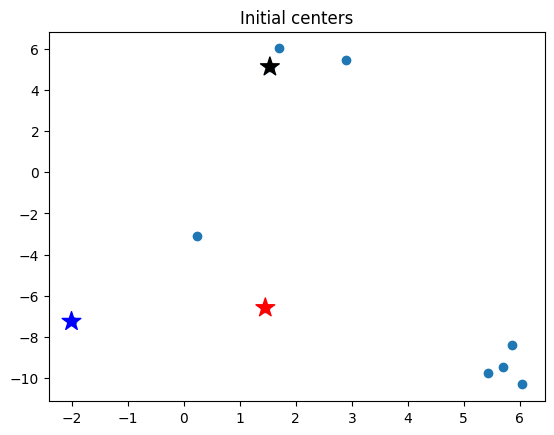

In [75]:
plt.scatter(X[:, 0], X[:, 1], marker="o")
plt.scatter(centers[:, 0], centers[:, 1], c=colours, marker="*", s=200)
plt.title("Initial centers");

#### Iterative process

repeat

- Assign each example to the closest center. (`update_Z`)
- Estimate new centers as _average_ of observations in a cluster. (`update_centers`)

until **centers stop changing** or **maximum iterations have reached**.

#### How to find closest centers?

- First step in the iterative process is assigning examples to the closest center.
- Let's consider distance of an example to all centers and assign that example to the closest center.  

/tmp/ipykernel_428/2411277798.py:39: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  l = np.row_stack((point, centroids[i, :]))


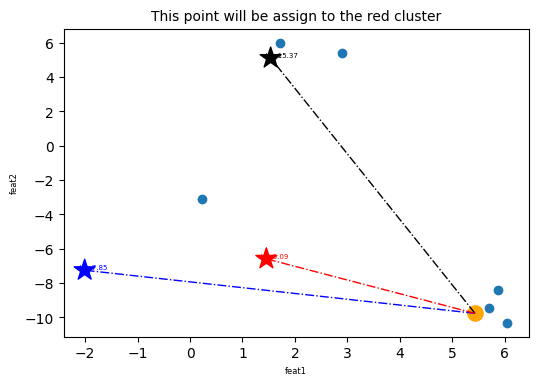

In [76]:
plot_example_dist(toy_df, centers_df, 6, 4)

#### How to find closest centers?

- Similarly, we can make cluster assignments for all points by calculating distances of all examples to the centers and assigning it to the cluster with smallest distance.  

### How to update centers?   

- With the new cluster assignments for our data points, we update cluster centers.
- New cluster centers are means of data points in each cluster.

#### Visualization of the Centroid Update

### Iteration 1: Step 1

- Assign each example to the closest cluster center.


In [77]:
dist, Z = update_Z(X, centers)
Z

array([2, 0, 2, 0, 2, 2, 1, 2, 0, 2])

- This is the current cluster assignment.

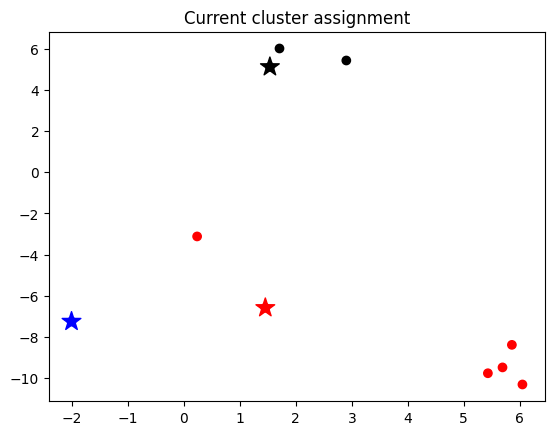

In [78]:
plot_current_assinment(X, Z, centers)

### Iteration 1: Step 2
- Estimate new centers as _average_ of observations in a cluster.

In [79]:
new_centers_it1 = update_centers(X, Z, centers, k)

- This is how the centers moved in this iteration.

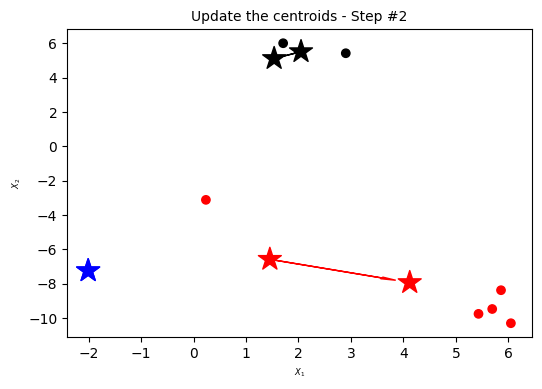

In [80]:
plot_update_centroid(toy_df, 6, 4, new_centers_it1, centers, dist)

### Iteration 2: step 1

- Assign each example to the closest cluster center.

In [81]:
dist, Z = update_Z(X, new_centers_it1)
Z

array([2, 0, 1, 0, 2, 2, 1, 2, 0, 2])

In [82]:
dist

array([[15.42510922,  8.01566052,  2.19962711],
       [ 0.59853464, 13.76280538, 14.14914423],
       [ 8.81959206,  4.69870403,  6.18895669],
       [ 0.85782129, 13.5865701 , 13.41432622],
       [14.40731426,  7.94840674,  1.79516479],
       [16.31503124,  8.61611362,  3.05291946],
       [13.38890418,  0.        ,  6.16645506],
       [12.11070549,  3.5252805 ,  2.98953059],
       [ 0.65057235, 12.85674577, 13.30220745],
       [15.64183625,  7.85104763,  2.24432374]])

- This is the current cluster assignment.

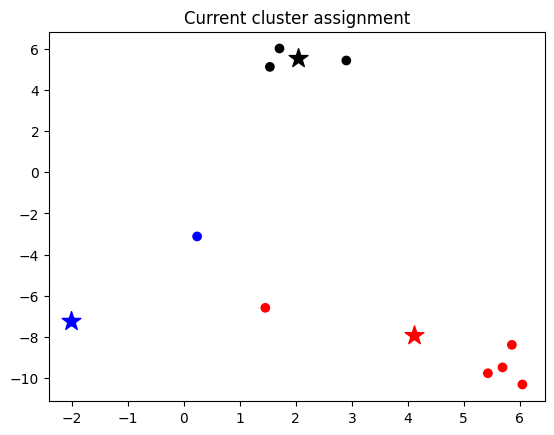

In [83]:
plot_current_assinment(X, Z, new_centers_it1)

### Iteration 2: step 2

- Estimate new centers as _average_ of observations in a cluster.

In [84]:
new_centers_it2 = update_centers(X, Z, new_centers_it1, k)

- This is how the centers moved in this iteration.

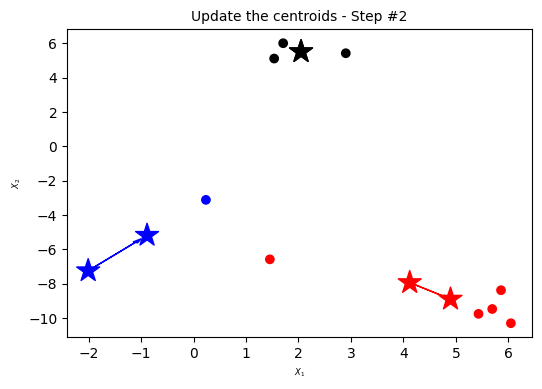

In [85]:
plot_update_centroid(toy_df, 6, 4, new_centers_it2, new_centers_it1, dist)

### Iteration 3: step 1

In [86]:
dist, Z = update_Z(X, new_centers_it2)
Z

array([2, 0, 1, 0, 2, 2, 1, 1, 0, 2])

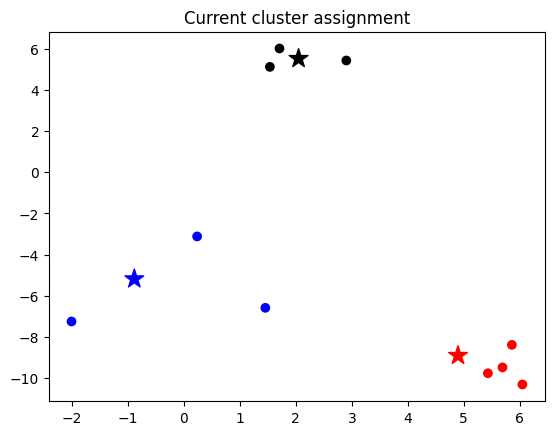

In [87]:
plot_current_assinment(X, Z, new_centers_it2)

In [88]:
new_centers_it3 = update_centers(X, Z, new_centers_it2, k)

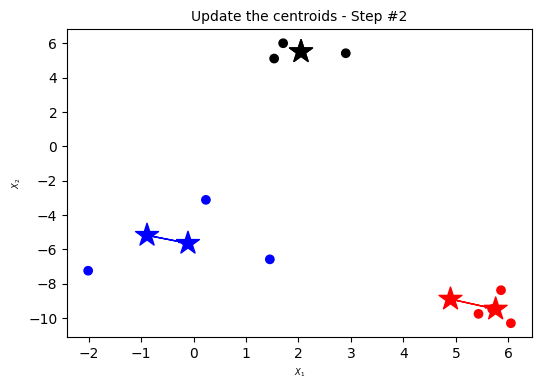

In [89]:
plot_update_centroid(toy_df, 6, 4, new_centers_it3, new_centers_it2, dist)

### Iteration 4: step 1

In [90]:
dist, Z = update_Z(X, new_centers_it3)
Z

array([2, 0, 1, 0, 2, 2, 1, 1, 0, 2])

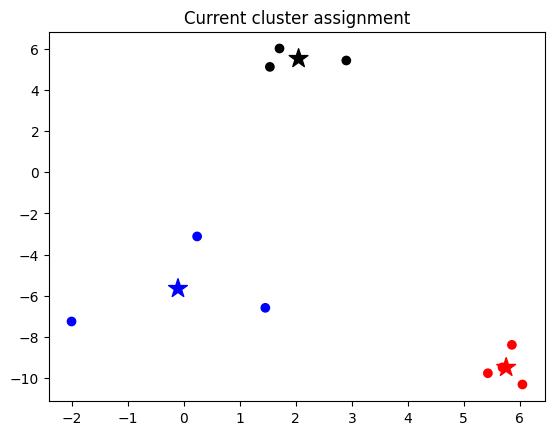

In [91]:
plot_current_assinment(X, Z, new_centers_it3)

### Iteration 4: step 2

In [92]:
new_centers_it4 = update_centers(X, Z, new_centers_it3, k)

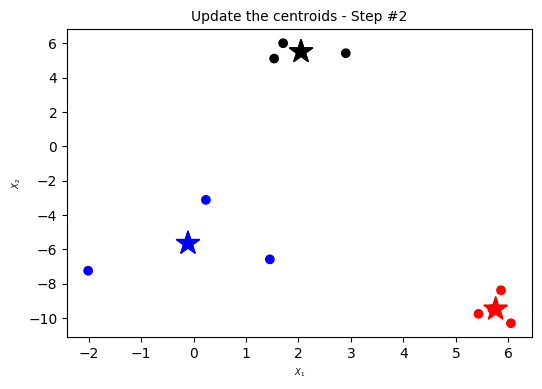

In [93]:
plot_update_centroid(toy_df, 6, 4, new_centers_it4, new_centers_it3, dist)

### Iteration 5: step 1

In [94]:
dist, Z = update_Z(X, new_centers_it4)
Z

array([2, 0, 1, 0, 2, 2, 1, 1, 0, 2])

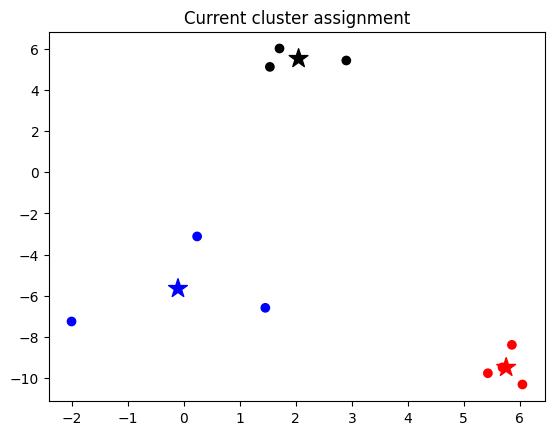

In [95]:
plot_current_assinment(X, Z, new_centers_it4)

### Iteration 5: step 2


In [96]:
new_centers_it5 = update_centers(X, Z, new_centers_it4, k)

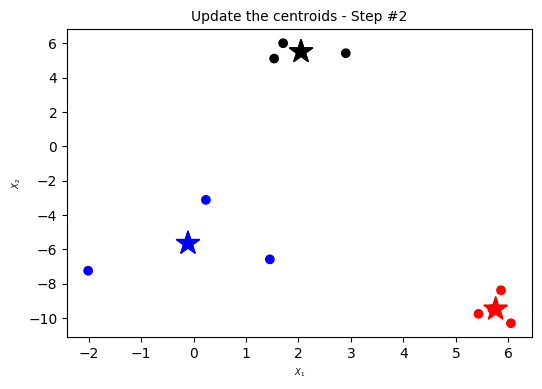

In [97]:
plot_update_centroid(toy_df, 6, 4, new_centers_it5, new_centers_it4, dist)

### When to stop?

- Seems like our centroids aren't changing anymore.
- The algorithm has converged. So we stop!
- K-Means always converges. It doesn't mean it finds the "right" clusters. It can converge to a sub-optimal solution.   

Initialization is crucial. We'll talk about it in a bit.

## Different Initializations

### A comment on initialization

- The initialization of K-Means is stochastic, can this affect the results?
    - Yes! Big time.  
- Let's  look at an example.

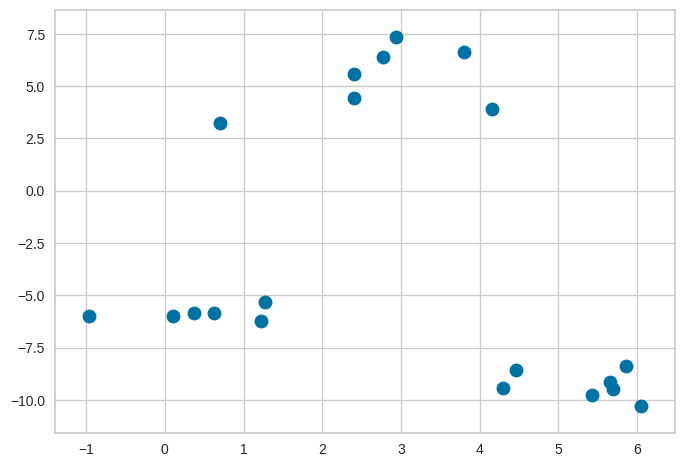

In [115]:
X, y = make_blobs(n_samples=20, centers=3, n_features=2, random_state=10)
mglearn.discrete_scatter(X[:, 0], X[:, 1], markers="o");

In [116]:
k = 3
n_examples = X.shape[0]
toy_df = pd.DataFrame(X, columns=["feat1", "feat2"])

### Example: Bad initialization

In [117]:
np.random.seed(seed=10)
centroids_idx = np.random.choice(range(0, n_examples), size=k)
centroids = X[centroids_idx]

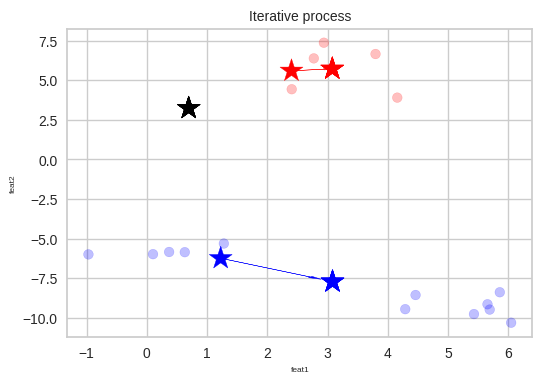

In [118]:
plot_iterative(toy_df, 6, 4, centroids)

### Example: Better initialization
The following initialization seems much better.

In [119]:
np.random.seed(seed=2)
centroids_idx = np.random.choice(range(0, n_examples), size=k)
centroids = X[centroids_idx]

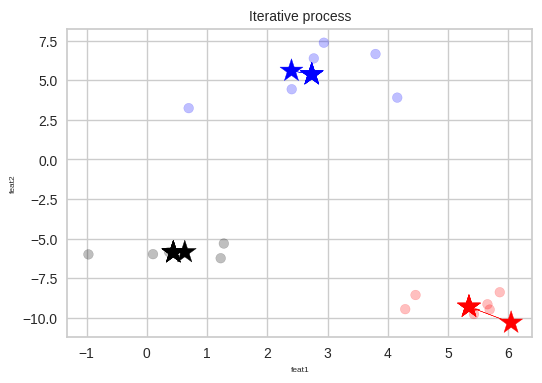

In [120]:
plot_iterative(toy_df, 6, 4, centroids)

/tmp/ipykernel_428/3516963616.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


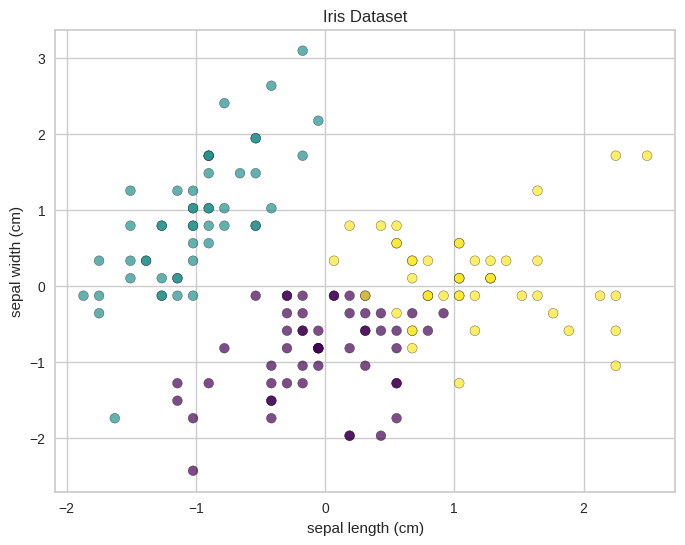

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# Load the Iris dataset
iris = load_iris()
X = iris.data  # Features

# Standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering
k = 3  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Cluster labels
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Visualizing the clusters (Using first two features for 2D visualization)
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.7)
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("Iris Dataset")
plt.legend()
plt.show()


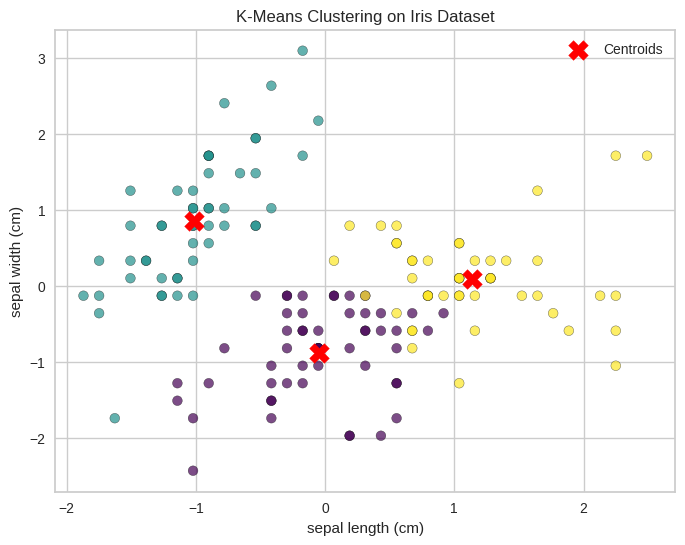

In [127]:
# Visualizing the clusters (Using first two features for 2D visualization)
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', edgecolors='k', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title("K-Means Clustering on Iris Dataset")
plt.legend()
plt.show()

### What can we do about it?

- One strategy is to run the algorithm several times.
    - Check out `n_init` parameter of [`sklearn`'s `KMeans`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).
- Is it possible to pick `K` in a smart way?
    - Yes! We can use the so-called [K-Means++](http://ilpubs.stanford.edu:8090/778/1/2006-13.pdf).
    - Intuitively, it picks the initial centroids which are far away from each other.
    - In other words, K-Means++ gives more chance to select points that are far away from centroids already picked.    
    - By default `sklearn` uses this strategy for initialization.

## Choosing K

### Iris Dataset Example

- Let's use the K-means on the iris dataset.

In [98]:
## Iris dataset
iris = datasets.load_iris()  # loading the iris dataset
features = iris.data  # get the input data
labels = iris.target_names[
    iris.target
]  # get the targets, in this case the types of the Iris flower

iris_df = pd.DataFrame(features, columns=iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [99]:
np.unique(labels)

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [100]:
# Reducing the dimensionality for plotting purposes
# (We're going to learn more about it later in the course)
pca = PCA(n_components=2)
pca.fit(features)
data_iris = pd.DataFrame(pca.transform(features), columns=["$Z_1$", "$Z_2$"])
data_iris["target"] = labels

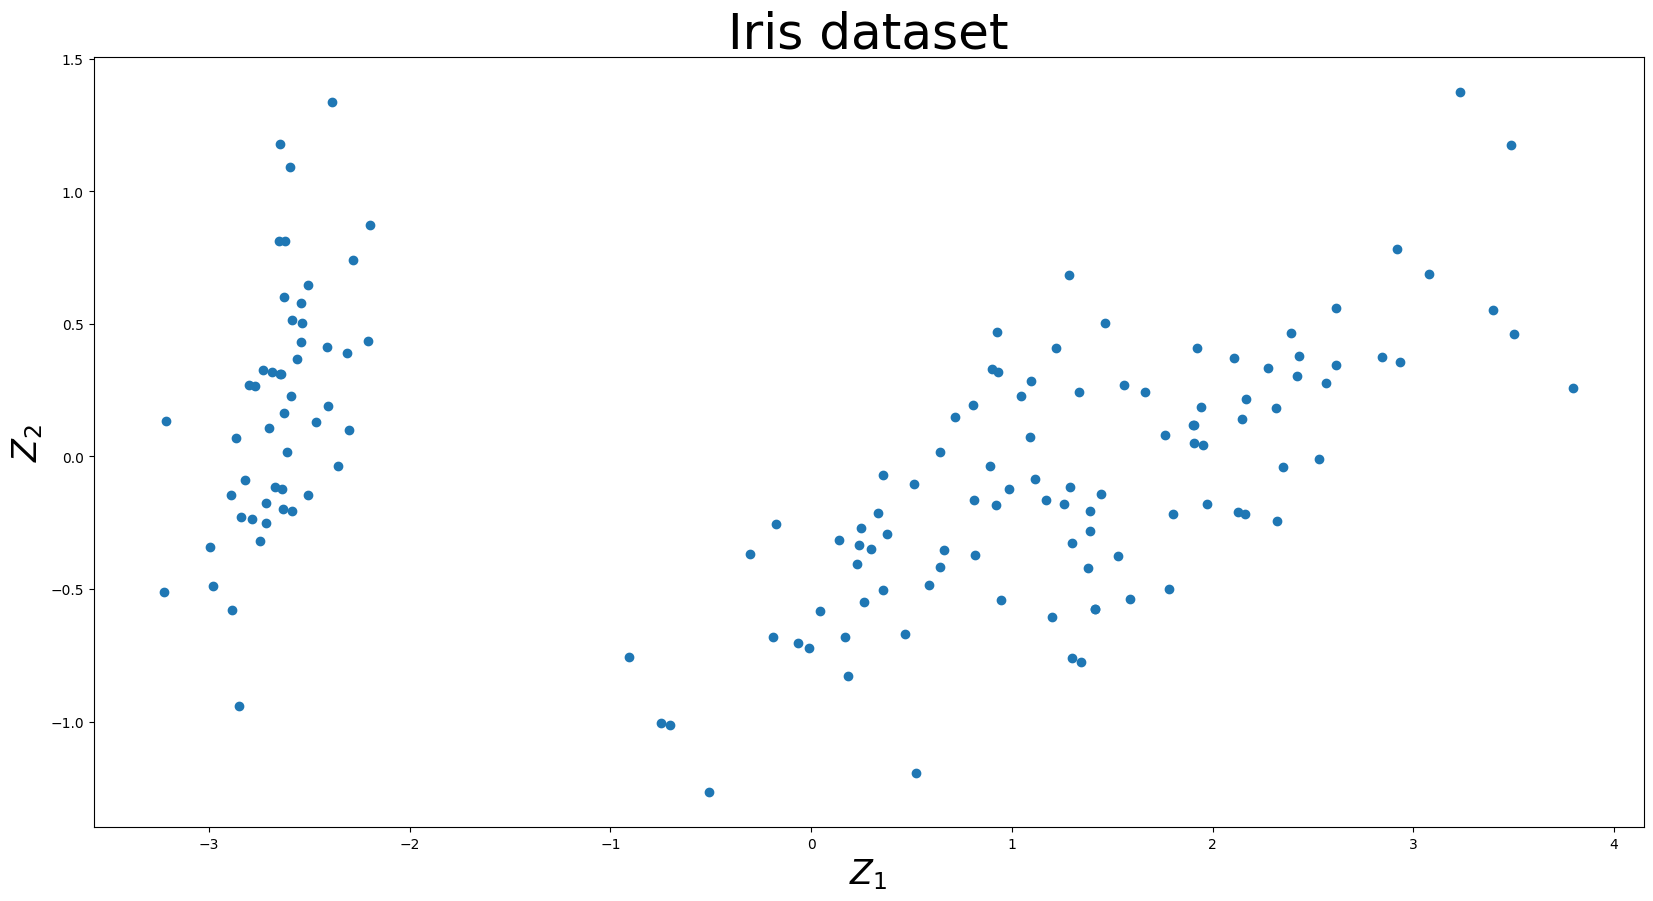

In [101]:
plot_unsup(data_iris, 20, 10, "Iris dataset")

#### Initialization

- In this case, we know that $k=3$;
- We are going to pick three points at random to use as initial centroids;

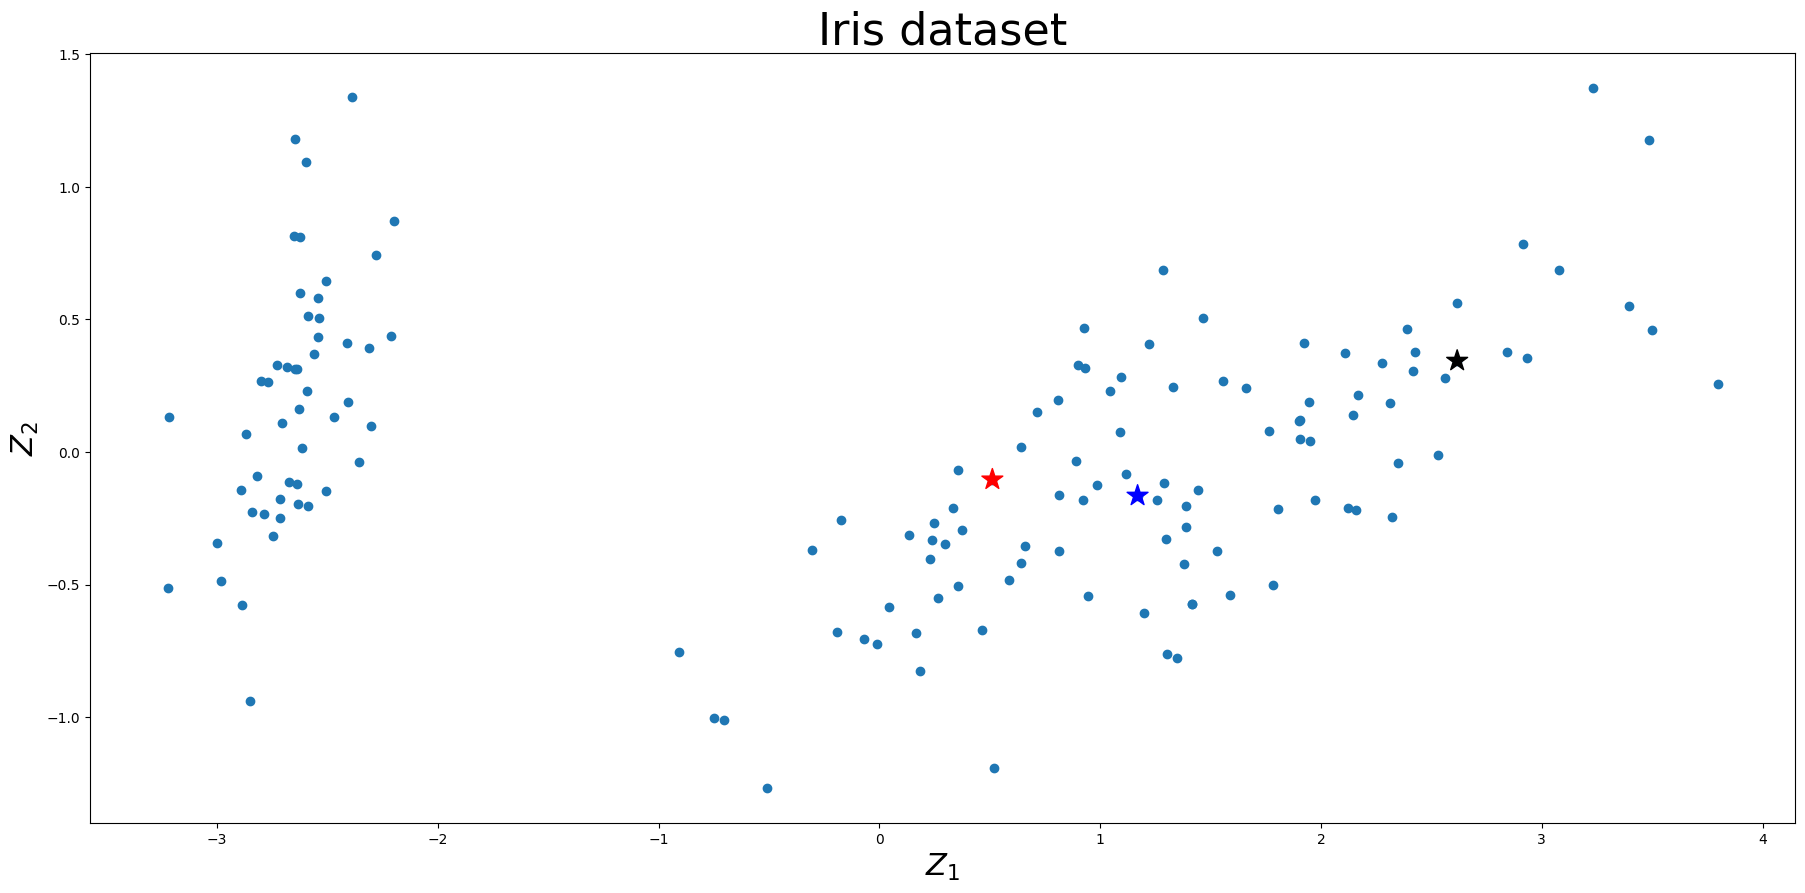

In [102]:
# RANDOM initialization
k = 3
centroids = np.random.choice(range(0, 150), size=k)
centroids = data_iris.iloc[centroids, 0:2]
plot_intial_center(data_iris, centroids, 22, 10, title="Iris dataset")

- Next, for each point in the dataset, we calculate the distance to each one of the centroids;


- Let's do it for one point as example:

/tmp/ipykernel_428/2411277798.py:39: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  l = np.row_stack((point, centroids[i, :]))


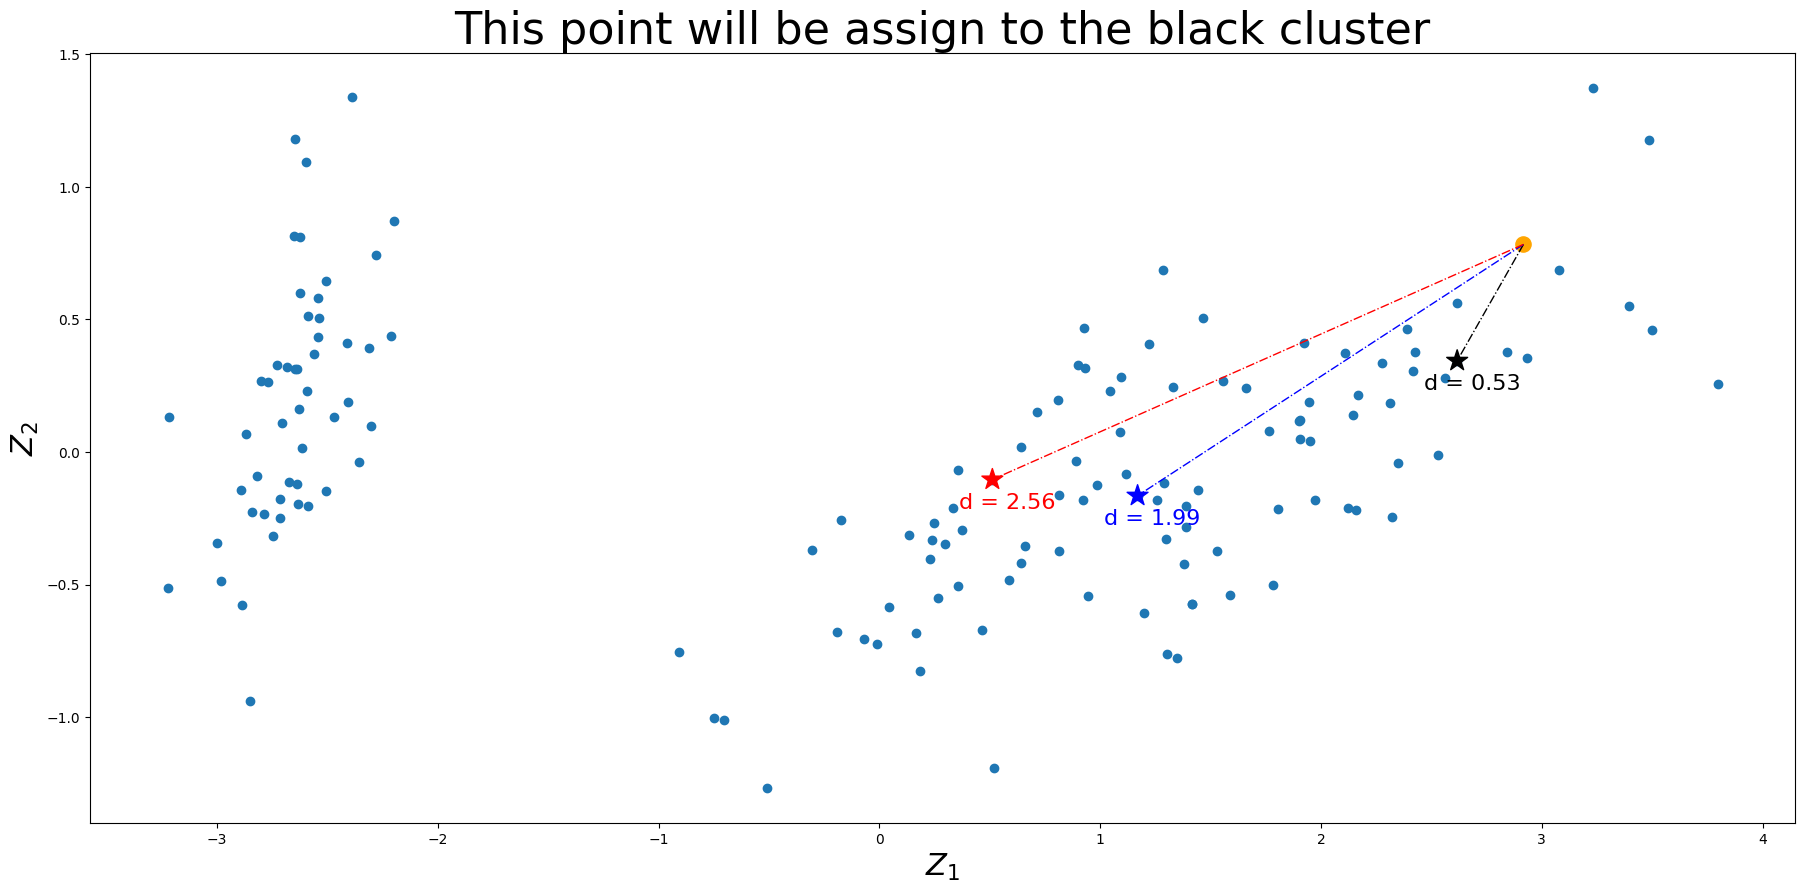

In [103]:
plot_example_dist(data_iris, centroids, 22, 10)

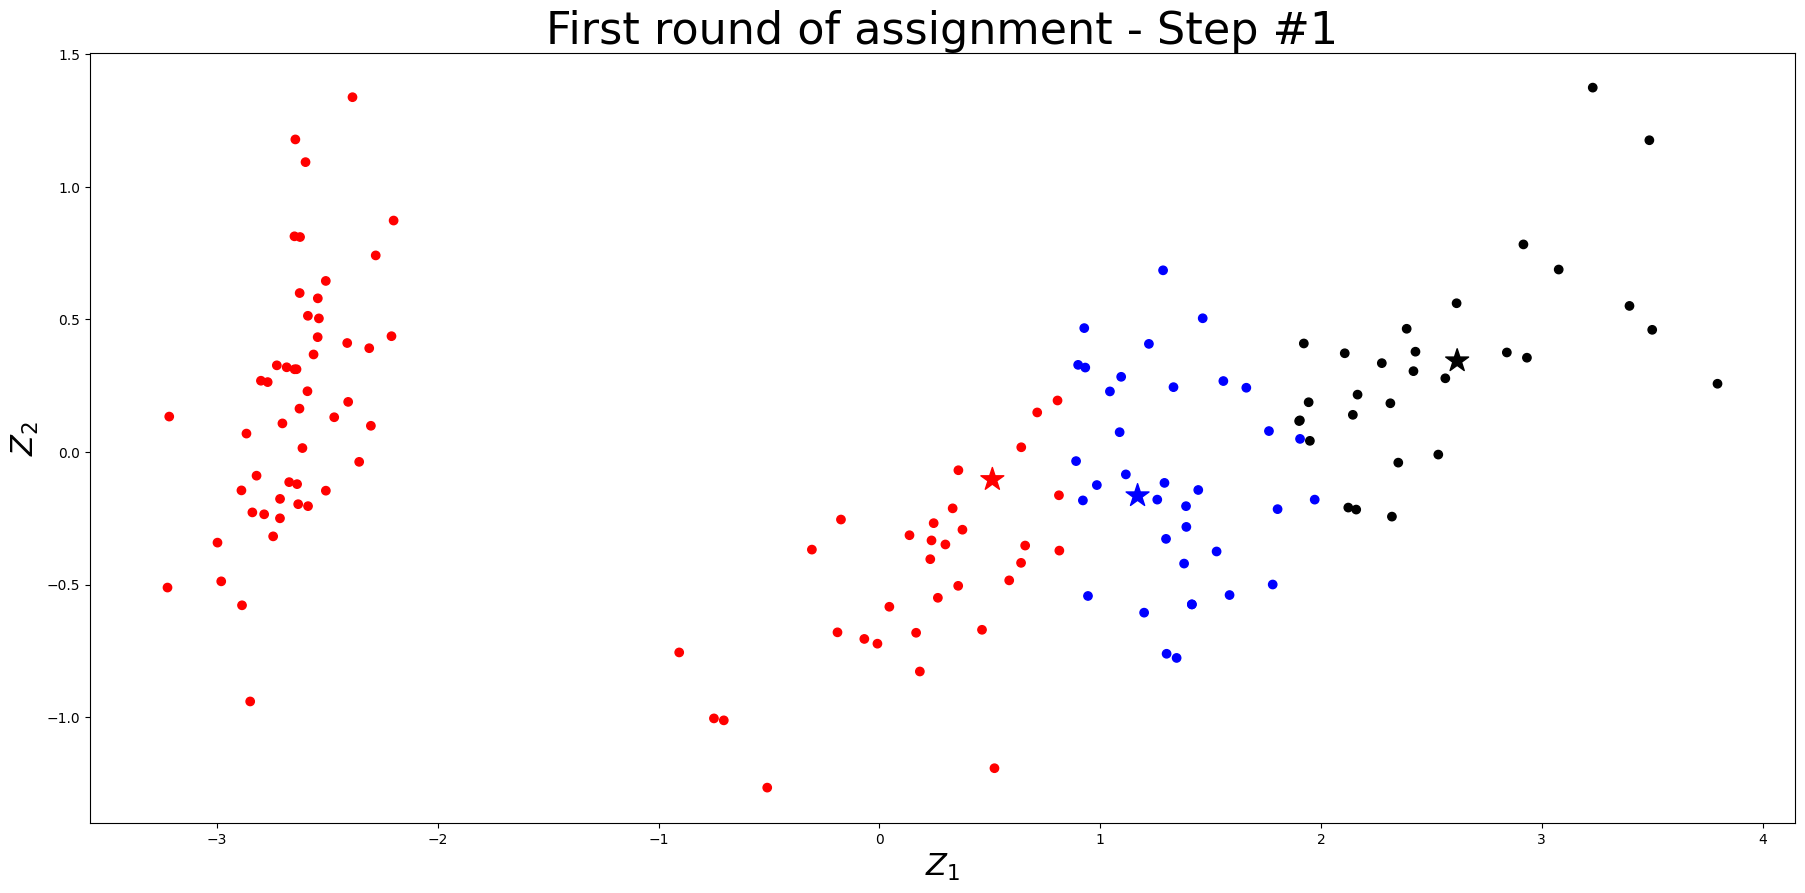

In [104]:
from scipy.spatial import distance
dist = distance.cdist(data_iris.iloc[:, 0:2], centroids.iloc[:, 0:2])
plot_first_assignment(data_iris, centroids, dist, 22, 10)

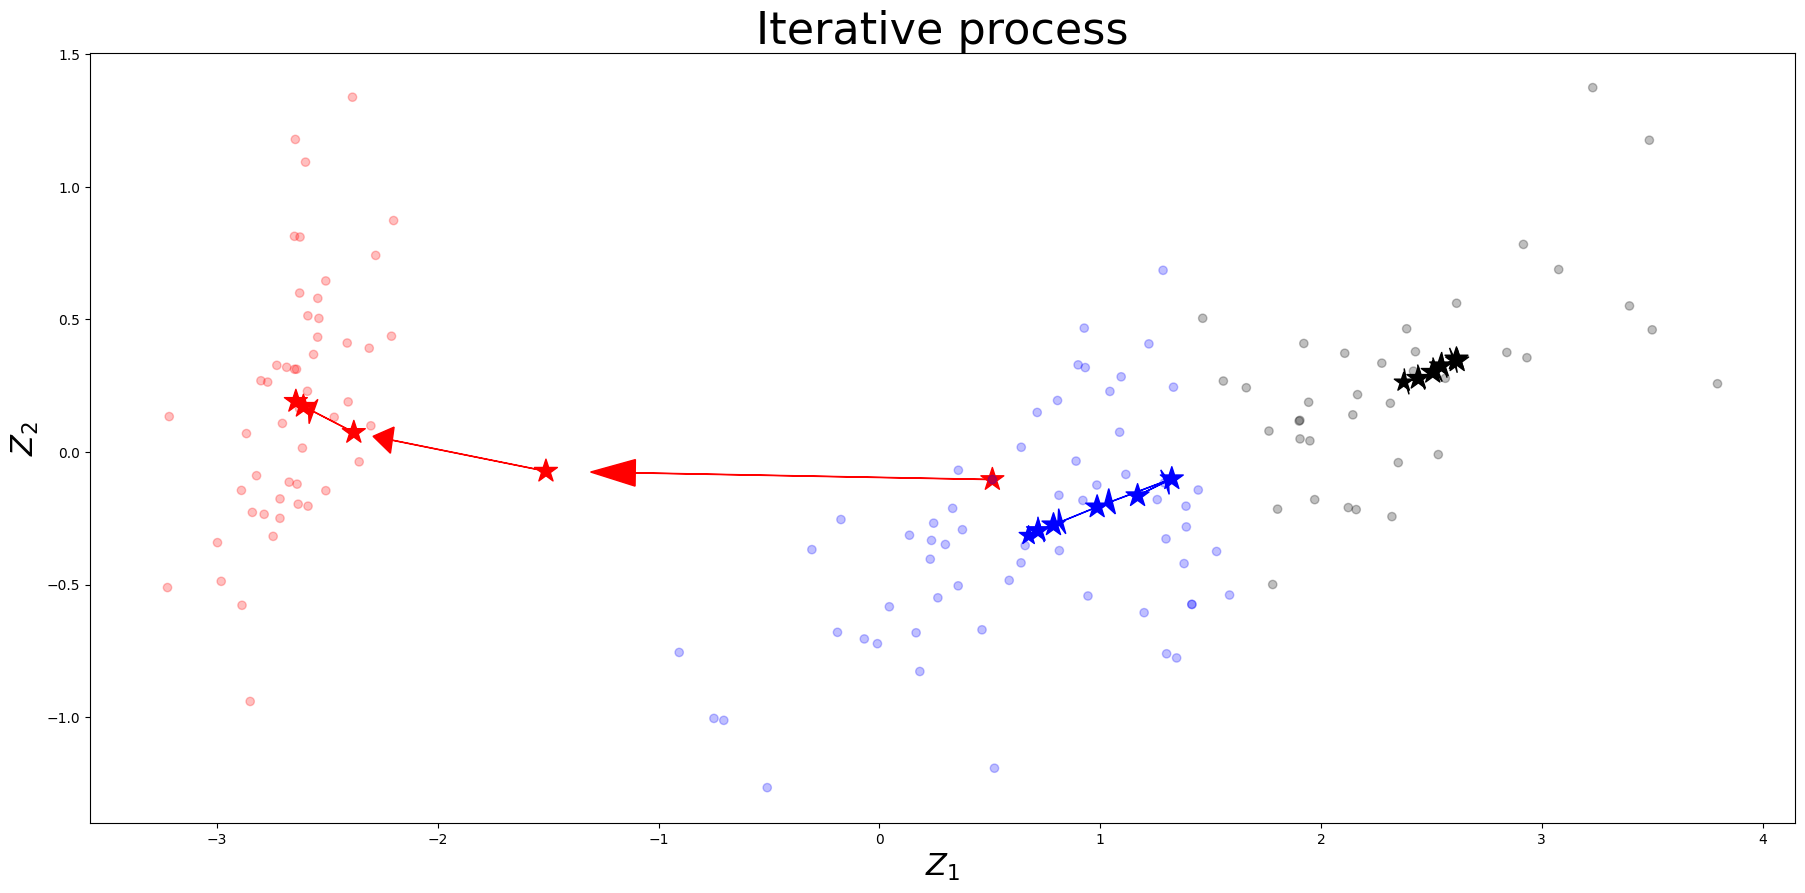

In [105]:
plot_iterative(data_iris, 22, 10, centroids.to_numpy())

### Hyperparameter tuning for K

- K-Means takes K (`n_clusters` in `sklearn`) as a hyperparameter. How do we pick K?

- In supervised setting we carried out hyperparameter optimization based on cross-validation scores.

- Since in unsupervised learning we do not have the target values, it becomes difficult to objectively measure the effectiveness of the algorithms.

- There is no definitive approach.

- However, some strategies might be useful to help you determine K.

### Method 1: The Elbow method

- This method looks at the sum of **within-cluster sum of squares (WCSS)**, which is also referred to as **inertia**.
- The intra-cluster distance in our toy example above is given as   

$$\sum_{P_i \in C_1}  distance(P_i, C_1)^2 + \sum_{P_i \in C_2}  distance(P_i, C_2)^2 + \sum_{P_i \in C_3} distance(P_i, C_3)^2$$

Where
- $C_1, C_2, C_3$ are centroids
- $P_i$s are points within that cluster
- $distance$ is the usual Euclidean distance.

#### Toy dataset



You can access this intra-cluster distance or inertia as follows.

In [109]:
def plot_elbow(w, h, inertia_values):
    plt.figure(figsize=(w, h))
    plt.axvline(x=3, linestyle="-.", c="black")
    plt.plot(range(1, 10), inertia_values, "-o")
    ax = plt.gca()
    ax.tick_params("both", labelsize=(w + h) / 2)
    ax.set_xlabel("K", fontsize=w)
    ax.set_ylabel("Inertia", fontsize=w)

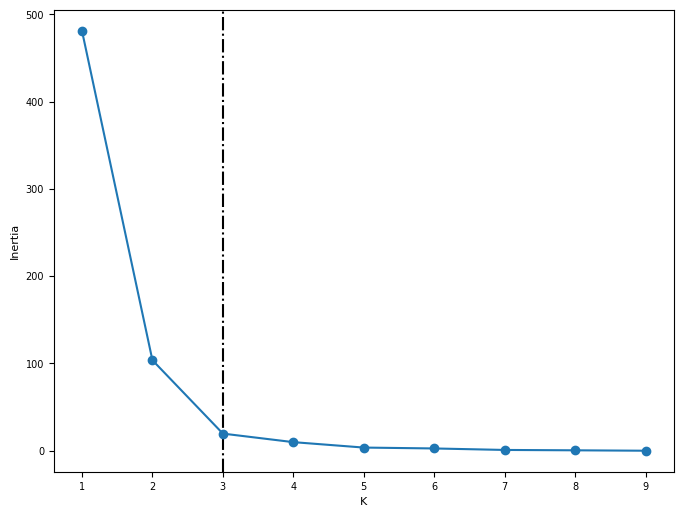

In [110]:
inertia_values = list()
for k in range(1, 10):
    inertia_values.append(KMeans(n_clusters=k).fit(toy_df).inertia_)
plot_elbow(8, 6, inertia_values)

#### Random dataset

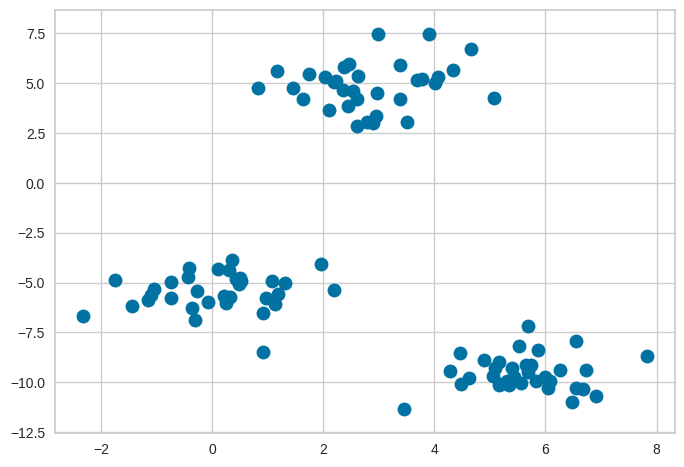

In [121]:
X, y = make_blobs(centers=3, n_features=2, random_state=10)
mglearn.discrete_scatter(X[:, 0], X[:, 1], markers="o");

In [123]:
d = {"K": [], "inertia": []}
for k in range(1, 10):
    model = KMeans(n_clusters=k).fit(X)
    d["K"].append(k)
    d["inertia"].append(model.inertia_)

In [124]:
pd.DataFrame(d)

,K,inertia
0,1,4372.460950
1,2,976.877334
2,3,186.365886
3,4,163.941121
4,5,159.602291
5,6,113.178527
6,7,100.848704
7,8,96.048544
8,9,79.943371


- The inertia decreases as K increases.
- Question: Do we want inertia to be small or large?
- The problem is that we can't just look for a $k$ that minimizes inertia because it decreases as $k$ increases.
    - If I have number of clusters = number of examples, each example will have its own cluster and the intra-cluster distance will be 0.  
- Instead we evaluate the trade-off: "small k" vs "small intra-cluster distances".

- From the above plot, we could argue that three clusters (the point of inflection on the curve) are enough.
- The inertia decreases when clusters are greater than 3. However it's not a big improvement and so we prefer K=3.
- In this toy example, it's the plot is kind of clear and easy to interpret but it can be hard to interpret in real life examples.

There is a package called [`yellowbrick`](https://www.scikit-yb.org/en/latest/api/cluster/elbow.html) which can be used to create these plots conveniently.

In [111]:
#!pip install yellowbrick

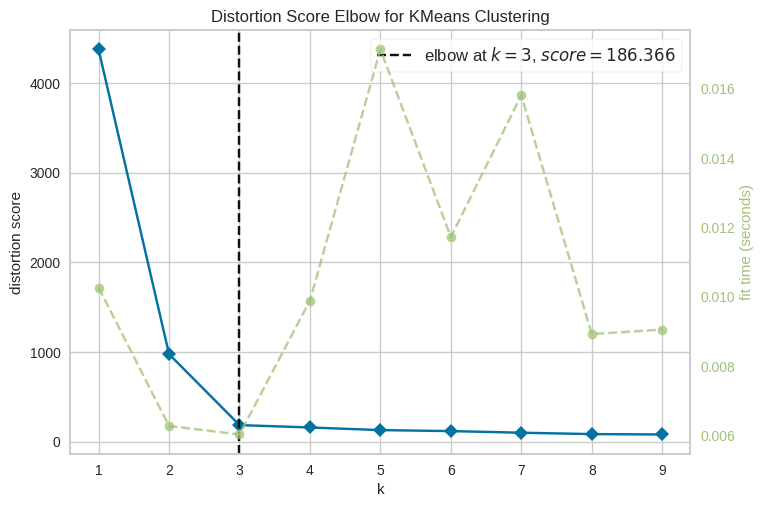

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [112]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans()
visualizer = KElbowVisualizer(model, k=(1, 10))

visualizer.fit(X)  # Fit the data to the visualizer
visualizer.show()

### Method 2: Silhouette score


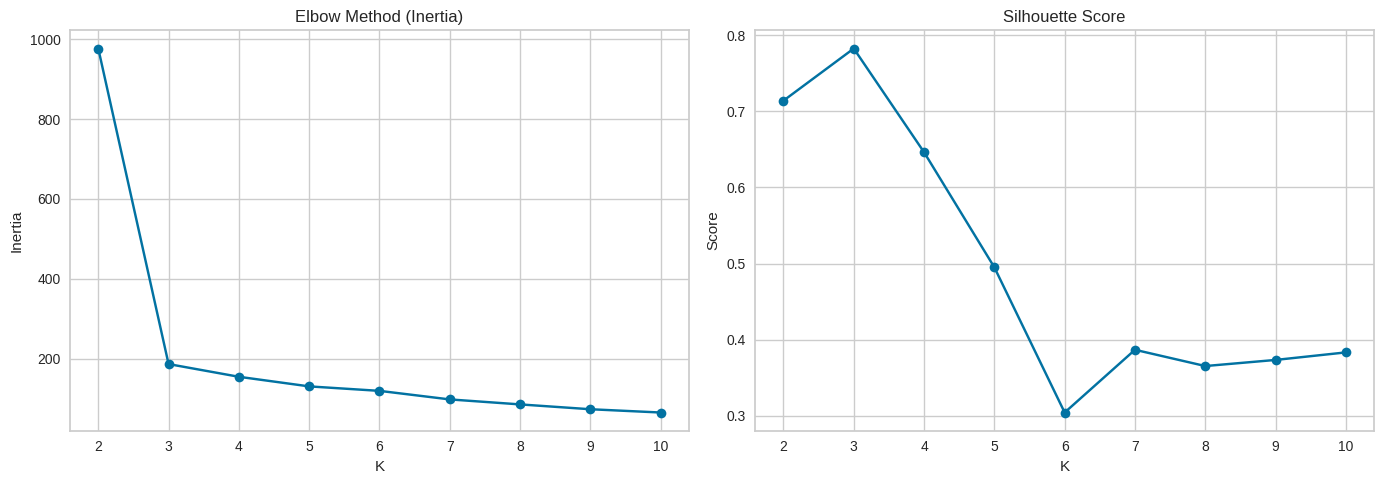

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score


# Range of K
k_values = range(2, 11)  # silhouette requires k >= 2

inertia_values = []
silhouette_values = []

# Fit models
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X, labels))

# -------------------------
# Plot both metrics
# -------------------------
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax[0].plot(k_values, inertia_values, '-o')
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("K")
ax[0].set_ylabel("Inertia")

# Silhouette plot
ax[1].plot(k_values, silhouette_values, '-o')
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("K")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()